In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
import json
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

print("Imports completed.")

Imports completed.


In [ ]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 6

HEAD_EPOCHS = 15
FINE_TUNE_EPOCHS = 5
HEAD_LR = 1e-3
FINE_TUNE_LR = 1e-5
FINE_TUNE_LAYERS = 30

CLASSES = [
    "Diabetic Retinopathy", "Glaucoma", "Cataract",
    "AMD", "Hypertension", "Myopia"
]
EXCLUDED_CLASSES = ["Normal", "Others"]

for i, c in enumerate(CLASSES):
    print(f"{i}: {c}")

0: Diabetic Retinopathy
1: Glaucoma
2: Cataract
3: AMD
4: Hypertension
5: Myopia


In [ ]:
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
DATA_ROOT = Path("/content/drive/MyDrive/Cellula/EyeDisease/Data")

IMAGES_DIR = DATA_ROOT / "images"
METADATA_PATH = DATA_ROOT / "metadata.csv"
AUGMENTED_DIR = DATA_ROOT / "images_augmented_v2"
SPLIT_DIR = DATA_ROOT / "dataset_splits_v2"

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR = SPLIT_DIR / "val"
TEST_DIR = SPLIT_DIR / "test"

for p in [DATA_ROOT, TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(p, "->", p.exists())

/content/drive/MyDrive/Cellula/EyeDisease/Data -> True
/content/drive/MyDrive/Cellula/EyeDisease/Data/dataset_splits_v2/train -> True
/content/drive/MyDrive/Cellula/EyeDisease/Data/dataset_splits_v2/val -> True
/content/drive/MyDrive/Cellula/EyeDisease/Data/dataset_splits_v2/test -> True


In [ ]:
def get_subdirectories(path):
    return sorted([p for p in Path(path).iterdir() if p.is_dir()],
                  key=lambda x: x.name.lower())

def get_image_files(path):
    valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
    return [p for p in Path(path).rglob("*")
            if p.is_file() and p.suffix.lower() in valid_ext]

def normalize_class_name(name):
    return name.lower().replace("_", " ").replace("-", " ").strip()

def find_matching_folder(expected_name, folder_dict):
    exp = normalize_class_name(expected_name)
    matches = [p for n, p in folder_dict.items()
               if normalize_class_name(n) == exp]
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        raise RuntimeError(f"Multiple matches for '{expected_name}'")
    return None

In [ ]:
train_folders = {p.name: p for p in get_subdirectories(TRAIN_DIR)}
val_folders   = {p.name: p for p in get_subdirectories(VAL_DIR)}
test_folders  = {p.name: p for p in get_subdirectories(TEST_DIR)}

print("Train:", list(train_folders.keys()))
print("Val  :", list(val_folders.keys()))
print("Test :", list(test_folders.keys()))

Train: ['AMD', 'Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']
Val  : ['AMD', 'Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']
Test : ['AMD', 'Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']


In [ ]:
class_folder_map = {"train": {}, "val": {}, "test": {}}

for class_name in CLASSES:
    for split, folder_dict in [("train", train_folders),
                               ("val", val_folders),
                               ("test", test_folders)]:
        match = find_matching_folder(class_name, folder_dict)
        if match is None:
            raise FileNotFoundError(f"'{class_name}' missing in {split}")
        class_folder_map[split][class_name] = match

split_counts = {"train": {}, "val": {}, "test": {}}
for split in ["train", "val", "test"]:
    for class_name in CLASSES:
        split_counts[split][class_name] = len(
            get_image_files(class_folder_map[split][class_name])
        )

counts_df = pd.DataFrame(split_counts)
display(counts_df)
print("\nTotal per split:\n", counts_df.sum(axis=0))

,train,val,test
Diabetic Retinopathy,2800,617,617
Glaucoma,1500,139,140
Cataract,1000,51,51
AMD,1000,41,41
Hypertension,500,13,13
Myopia,1000,44,44



Total per split:
 train    7800
val       905
test      906
dtype: int64


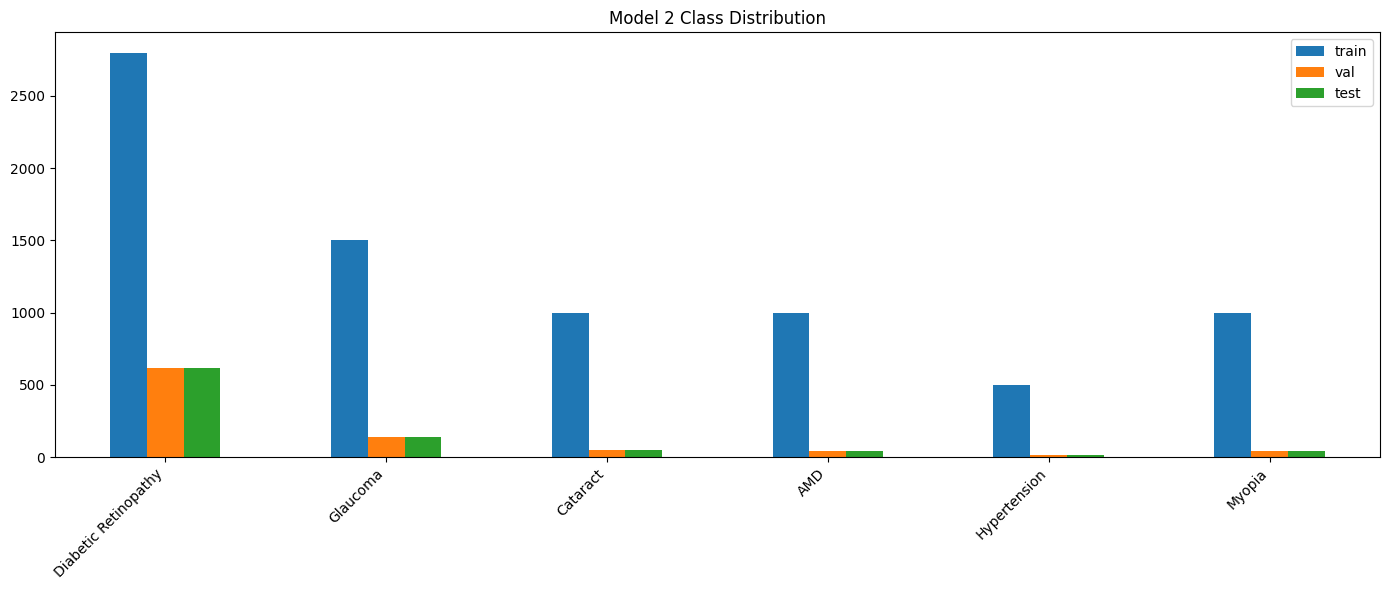

In [ ]:
ax = counts_df.plot(kind="bar", figsize=(14, 6))
plt.title("Model 2 Class Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

RESULTS_DIR = DATA_ROOT / "model2_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(RESULTS_DIR / "class_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
train_labels = []
for idx, cname in enumerate(CLASSES):
    train_labels.extend([idx] * split_counts["train"][cname])
train_labels = np.array(train_labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
class_weights = {int(i): float(w) for i, w in enumerate(weights)}
print(class_weights)

with open(RESULTS_DIR / "class_weights.json", "w") as f:
    json.dump({CLASSES[k]: v for k, v in class_weights.items()}, f, indent=4)

{0: 0.4642857142857143, 1: 0.8666666666666667, 2: 1.3, 3: 1.3, 4: 2.6, 5: 1.3}


In [ ]:
def build_file_label_list(class_map, classes):
    paths, labels = [], []
    for idx, cname in enumerate(classes):
        folder = class_map[cname]
        for img_path in get_image_files(folder):
            paths.append(str(img_path))
            labels.append(idx)
    return paths, labels

train_paths, train_labels = build_file_label_list(
    class_folder_map["train"], CLASSES)
val_paths,   val_labels   = build_file_label_list(
    class_folder_map["val"], CLASSES)
test_paths,  test_labels  = build_file_label_list(
    class_folder_map["test"], CLASSES)

print(f"Train: {len(train_paths)}")
print(f"Val  : {len(val_paths)}")
print(f"Test : {len(test_paths)}")

Train: 7800
Val  : 905
Test : 906


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img, label

def make_dataset(paths, labels, shuffle=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices(
        (tf.constant(paths), tf.constant(labels, dtype=tf.int32))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(paths), 2000), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, shuffle=True)
val_ds   = make_dataset(val_paths,   val_labels,   shuffle=False)
test_ds  = make_dataset(test_paths,  test_labels,  shuffle=False)

imgs, lbls = next(iter(train_ds))
print("Batch:", imgs.shape, lbls.shape)
print("Pixel range:",
      float(tf.reduce_min(imgs)), "-", float(tf.reduce_max(imgs)))

Batch: (32, 224, 224, 3) (32,)
Pixel range: 0.0 - 255.0


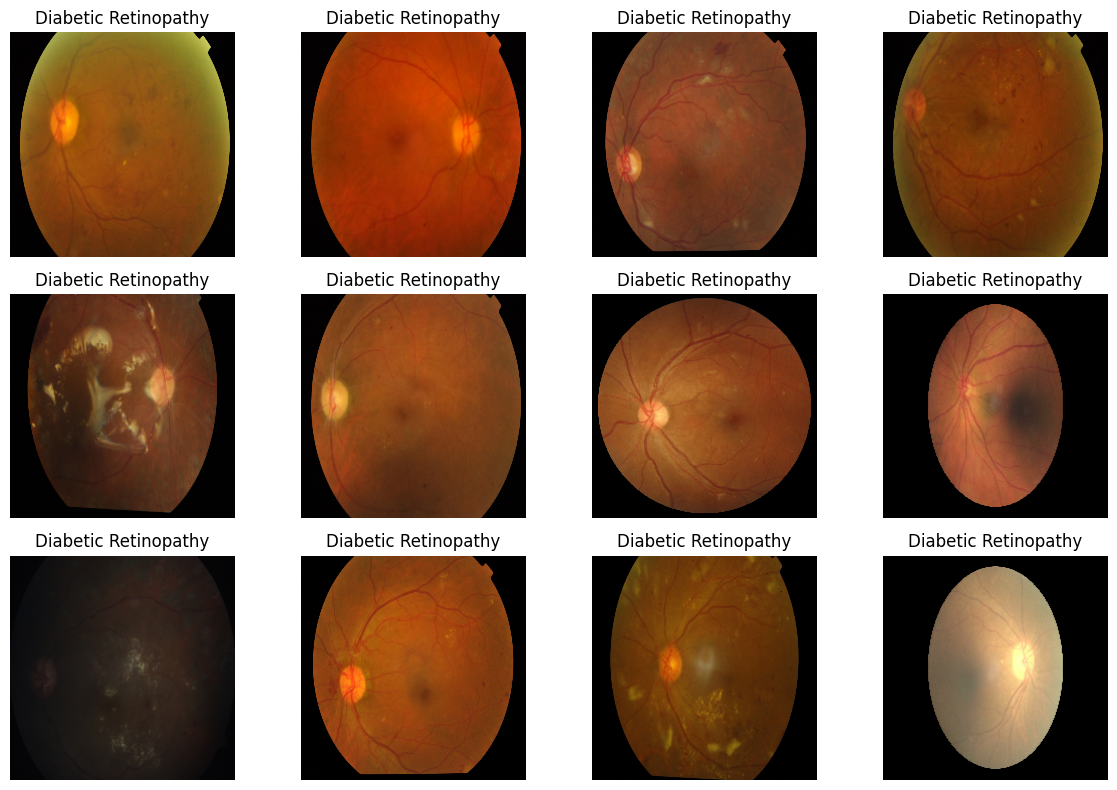

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(min(12, len(imgs))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(imgs[i].numpy().astype("uint8"))
    plt.title(CLASSES[int(lbls[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

inputs = layers.Input(shape=(*IMG_SIZE, 3), name="input_image")

# No augmentation – فقط preprocess
x = preprocess_input(inputs)

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False  # Stage 1

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.BatchNormalization(name="bn")(x)
x = layers.Dropout(0.40, name="dropout_1")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.30, name="dropout_2")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="classifier")(x)

model = Model(inputs, outputs, name="Model2_ResNet50_NoAug")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "Model2_ResNet50_NoAug"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_image[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_image[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_image[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn                  │ (None, 2048)      │      8,192 │ gap[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ bn[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_256 (Dense)   │ (None, 256)       │    524,544 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_256[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 6)         │      1,542 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,121,990 (92.02 MB)

 Trainable params: 530,182 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(HEAD_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

MODEL_DIR = Path("/content/drive/MyDrive/EyeDisease/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

STAGE1_BEST = MODEL_DIR / "model2_resnet50_noaug_stage1_best.keras"

callbacks_s1 = [
    tf.keras.callbacks.ModelCheckpoint(
        str(STAGE1_BEST),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("=" * 60)
print("STAGE 1 – Frozen ResNet50 (No Augmentation)")
print("=" * 60)

history_s1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_s1,
    verbose=1
)

STAGE 1 – Frozen ResNet50 (No Augmentation)
Epoch 1/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7736 - loss: 0.8052
Epoch 1: val_loss improved from None to 1.53055, saving model to /content/drive/MyDrive/EyeDisease/models/model2_resnet50_noaug_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EyeDisease/models/model2_resnet50_noaug_stage1_best.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 2607s 11s/step - accuracy: 0.7560 - loss: 1.1721 - val_accuracy: 0.4829 - val_loss: 1.5306 - learning_rate: 0.0010
Epoch 2/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.7690 - loss: 0.6961
Epoch 2: val_loss did not improve from 1.53055
244/244 ━━━━━━━━━━━━━━━━━━━━ 165s 673ms/step - accuracy: 0.7978 - loss: 0.6907 - val_accuracy: 0.5370 - val_loss: 1.5397 - learning_rate: 0.0010
Epoch 3/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.7755 - loss: 0.5502
Epoch 3: val_loss improved from 1.53055 to 1.30050, saving model to /content/drive/MyDrive/EyeDis

In [ ]:
s1_df = pd.DataFrame(history_s1.history)
display(s1_df)
print("Best Stage 1 epoch:", s1_df["val_loss"].idxmin() + 1)
print("Best Stage 1 val_loss:", s1_df["val_loss"].min())

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.756026,1.172137,0.482873,1.530554,0.00100
1,0.797821,0.690672,0.537017,1.539706,0.00100
2,0.809231,0.589623,0.569061,1.300503,0.00100
3,0.830769,0.495380,0.596685,1.114806,0.00100
4,0.848974,0.426269,0.590055,1.102875,0.00100
5,0.863077,0.393223,0.581215,1.135344,0.00100
6,0.869744,0.352974,0.595580,1.133519,0.00100
7,0.863205,0.348281,0.605525,1.102372,0.00050
8,0.870641,0.329338,0.600000,1.039886,0.00050
9,0.874615,0.317486,0.619889,1.039379,0.00050


Best Stage 1 epoch: 15
Best Stage 1 val_loss: 0.8902158737182617


In [ ]:
base_model.trainable = True

total_layers = len(base_model.layers)
freeze_until = max(0, total_layers - FINE_TUNE_LAYERS)

for i, layer in enumerate(base_model.layers):
    if i < freeze_until:
        layer.trainable = False
    else:
        # Keep BN frozen for stability
        layer.trainable = not isinstance(layer, layers.BatchNormalization)

trainable_backbone = sum(1 for l in base_model.layers if l.trainable)
print(f"Total backbone layers : {total_layers}")
print(f"Trainable backbone    : {trainable_backbone}")

trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_variables])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_variables])
print(f"Trainable params      : {trainable_params:,}")
print(f"Non-trainable params  : {non_trainable_params:,}")

Total backbone layers : 175
Trainable backbone    : 21
Trainable params      : 14,958,854
Non-trainable params  : 9,163,140


In [ ]:
# ============================================================
# RESUME FROM STAGE 1 CHECKPOINT
# ============================================================

STAGE1_BEST = MODEL_DIR / "model2_resnet50_noaug_stage1_best.keras"

print("Loading Stage 1 checkpoint...")
model = tf.keras.models.load_model(STAGE1_BEST)
print("✅ Model loaded")

# Unfreeze last 30 layers
base_model = model.get_layer("resnet50")
base_model.trainable = True

total_layers = len(base_model.layers)
freeze_until = max(0, total_layers - FINE_TUNE_LAYERS)

for i, layer in enumerate(base_model.layers):
    if i < freeze_until:
        layer.trainable = False
    else:
        layer.trainable = not isinstance(layer, tf.keras.layers.BatchNormalization)

print(f"Trainable backbone layers: {sum(1 for l in base_model.layers if l.trainable)}")

# Compile for Stage 2
model.compile(
    optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Ready for Stage 2")

Loading Stage 1 checkpoint...
✅ Model loaded
Trainable backbone layers: 21
✅ Ready for Stage 2


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

FINAL_BEST = MODEL_DIR / "model2_resnet50_noaug_best.keras"

callbacks_s2 = [
    tf.keras.callbacks.ModelCheckpoint(
        str(FINAL_BEST),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]

print("=" * 60)
print("STAGE 2 – Fine-tuning (No Augmentation)")
print("=" * 60)

history_s2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_s2,
    verbose=1
)

STAGE 2 – Fine-tuning (No Augmentation)
Epoch 1/5
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.9093 - loss: 0.1821
Epoch 1: val_loss improved from None to 0.76734, saving model to /content/drive/MyDrive/EyeDisease/models/model2_resnet50_noaug_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EyeDisease/models/model2_resnet50_noaug_best.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 189s 697ms/step - accuracy: 0.9047 - loss: 0.2421 - val_accuracy: 0.7094 - val_loss: 0.7673 - learning_rate: 1.0000e-05
Epoch 2/5
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.9099 - loss: 0.1768
Epoch 2: val_loss did not improve from 0.76734

Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
244/244 ━━━━━━━━━━━━━━━━━━━━ 163s 666ms/step - accuracy: 0.9058 - loss: 0.2266 - val_accuracy: 0.7193 - val_loss: 0.7902 - learning_rate: 1.0000e-05
Epoch 3/5
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.9060 - loss: 0.1631
Epoch 3: val_loss improved fr

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.756026,1.172137,0.482873,1.530554,0.001000
1,0.797821,0.690672,0.537017,1.539706,0.001000
2,0.809231,0.589623,0.569061,1.300503,0.001000
3,0.830769,0.495380,0.596685,1.114806,0.001000
4,0.848974,0.426269,0.590055,1.102875,0.001000
5,0.863077,0.393223,0.581215,1.135344,0.001000
6,0.869744,0.352974,0.595580,1.133519,0.001000
7,0.863205,0.348281,0.605525,1.102372,0.000500
8,0.870641,0.329338,0.600000,1.039886,0.000500
9,0.874615,0.317486,0.619889,1.039379,0.000500


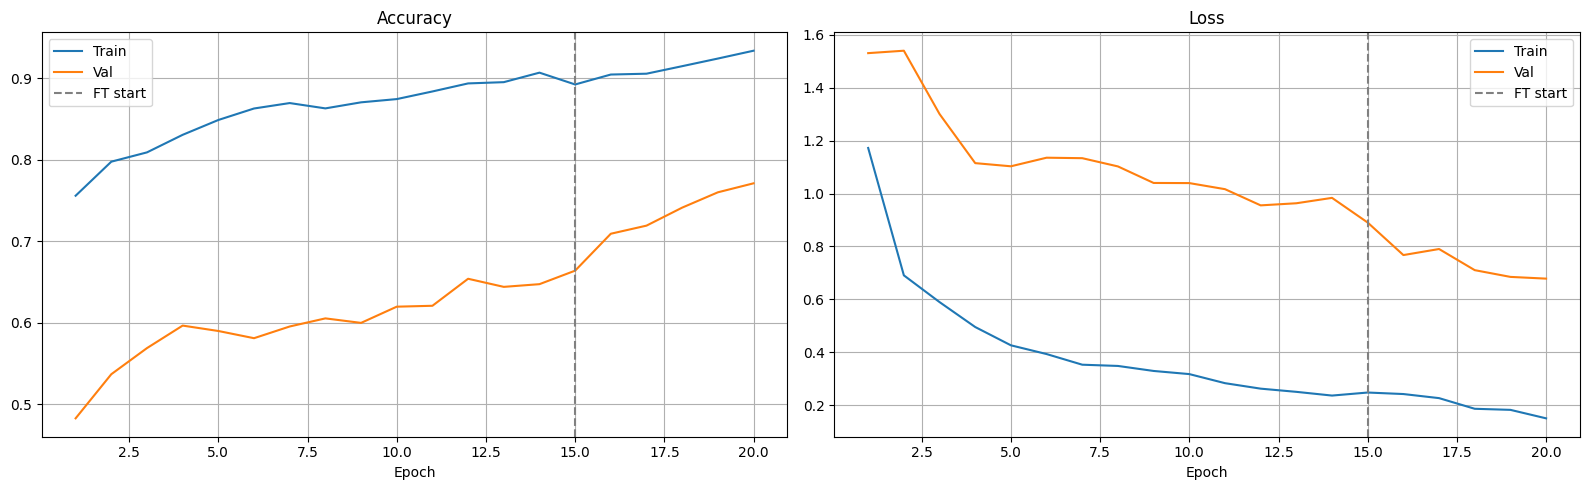

In [ ]:
history_combined = {}
for k in history_s1.history:
    history_combined[k] = history_s1.history[k] + history_s2.history.get(k, [])

combined_df = pd.DataFrame(history_combined)
display(combined_df)

epochs_range = range(1, len(combined_df) + 1)
stage1_end = len(history_s1.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(epochs_range, combined_df["accuracy"], label="Train")
axes[0].plot(epochs_range, combined_df["val_accuracy"], label="Val")
axes[0].axvline(stage1_end, ls="--", color="gray", label="FT start")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, combined_df["loss"], label="Train")
axes[1].plot(epochs_range, combined_df["val_loss"], label="Val")
axes[1].axvline(stage1_end, ls="--", color="gray", label="FT start")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# History
with open(RESULTS_DIR / "history.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history_combined.items()},
              f, indent=4)

# Class names
with open(RESULTS_DIR / "class_names.json", "w") as f:
    json.dump(CLASSES, f, indent=4)

# Config
training_config = {
    "seed": SEED,
    "img_size": list(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "num_classes": NUM_CLASSES,
    "classes": CLASSES,
    "excluded_classes": EXCLUDED_CLASSES,
    "backbone": "ResNet50",
    "weights": "imagenet",
    "augmentation": "NONE",
    "head_epochs": HEAD_EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS,
    "head_lr": HEAD_LR,
    "fine_tune_lr": FINE_TUNE_LR,
    "fine_tune_layers": FINE_TUNE_LAYERS
}
with open(RESULTS_DIR / "training_config.json", "w") as f:
    json.dump(training_config, f, indent=4)

print("Saved history, class names, config.")

Saved history, class names, config.


In [ ]:
if not FINAL_BEST.exists():
    raise FileNotFoundError(f"Best model not found: {FINAL_BEST}")

best_model = tf.keras.models.load_model(FINAL_BEST)
print("Loaded best model.")
print(f"Size: {FINAL_BEST.stat().st_size / (1024**2):.2f} MB")

Loaded best model.
Size: 206.79 MB


In [ ]:
y_true, y_pred = [], []

for batch_imgs, batch_lbls in test_ds:
    preds = best_model(batch_imgs, training=False)
    y_pred.extend(tf.argmax(preds, axis=1).numpy().tolist())
    y_true.extend(batch_lbls.numpy().tolist())

    del batch_imgs, batch_lbls, preds

y_true = np.asarray(y_true, dtype=np.int32)
y_pred = np.asarray(y_pred, dtype=np.int32)

print("Test labels:", len(y_true))
print("Predictions:", len(y_pred))

Test labels: 906
Predictions: 906


In [ ]:
test_accuracy = accuracy_score(y_true, y_pred)
macro_p = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_r = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
w_p = precision_score(y_true, y_pred, average="weighted", zero_division=0)
w_r = recall_score(y_true, y_pred, average="weighted", zero_division=0)
w_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("=" * 60)
print("TEST METRICS (No Augmentation)")
print("=" * 60)
print(f"Accuracy          : {test_accuracy:.4f}")
print(f"Macro Precision   : {macro_p:.4f}")
print(f"Macro Recall      : {macro_r:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")
print(f"Weighted Precision: {w_p:.4f}")
print(f"Weighted Recall   : {w_r:.4f}")
print(f"Weighted F1       : {w_f1:.4f}")

TEST METRICS (No Augmentation)
Accuracy          : 0.7517
Macro Precision   : 0.5568
Macro Recall      : 0.6951
Macro F1          : 0.5992
Weighted Precision: 0.8342
Weighted Recall   : 0.7517
Weighted F1       : 0.7793


In [ ]:
report_dict = classification_report(
    y_true, y_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=CLASSES,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()

print(classification_report(
    y_true, y_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=CLASSES,
    zero_division=0
))

per_class_metrics = report_df.loc[CLASSES,
    ["precision", "recall", "f1-score", "support"]].copy()
display(per_class_metrics)

                      precision    recall  f1-score   support

Diabetic Retinopathy       0.94      0.74      0.83       617
            Glaucoma       0.71      0.81      0.76       140
            Cataract       0.62      0.84      0.72        51
                 AMD       0.24      0.56      0.34        41
        Hypertension       0.10      0.31      0.15        13
              Myopia       0.73      0.91      0.81        44

            accuracy                           0.75       906
           macro avg       0.56      0.70      0.60       906
        weighted avg       0.83      0.75      0.78       906



,precision,recall,f1-score,support
Diabetic Retinopathy,0.942387,0.742301,0.830462,617.0
Glaucoma,0.710692,0.807143,0.755853,140.0
Cataract,0.623188,0.843137,0.716667,51.0
AMD,0.239583,0.560976,0.335766,41.0
Hypertension,0.097561,0.307692,0.148148,13.0
Myopia,0.727273,0.909091,0.808081,44.0


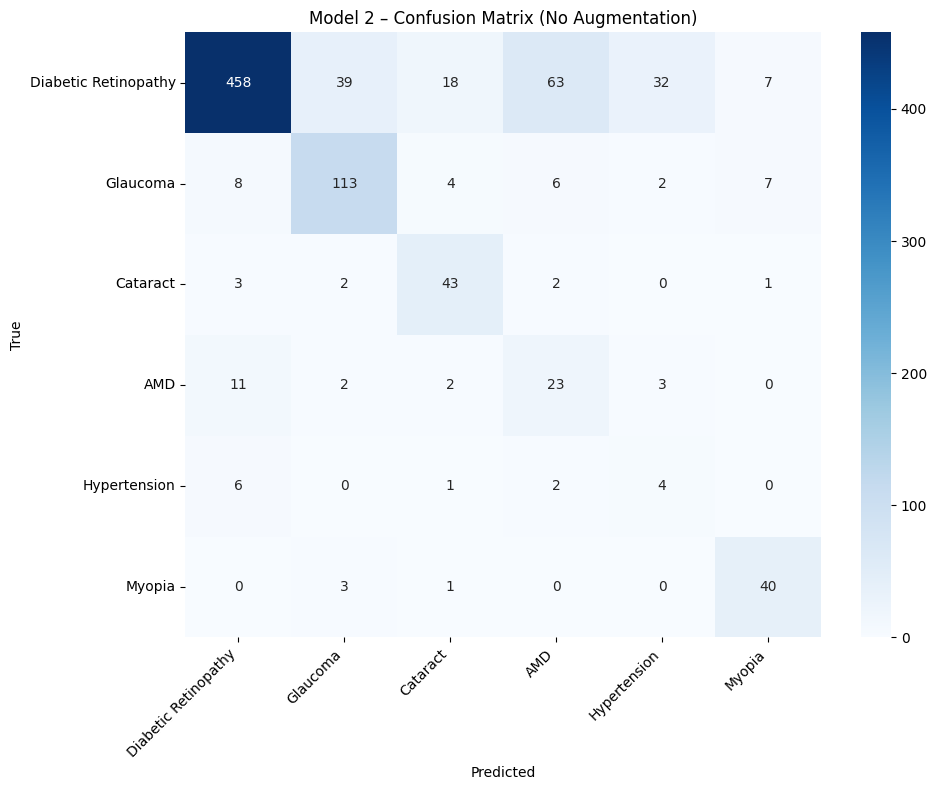

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASSES, yticklabels=CLASSES, cmap="Blues")
plt.title("Model 2 – Confusion Matrix (No Augmentation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()